# 🌊 LightGBM Deep Dive — Lag-Free Groundwater Crisis Predictor
## AquaVidarbha: ML-Based Spatio-Temporal Groundwater Depth Prediction

**Region:** Vidarbha, Maharashtra, India  
**Dataset:** `vidarbha_groundwater_extended_v2.csv` and model-ready training data  
**Target Variable:** `depth_mbgl`

This notebook mirrors the Random Forest cell-wise style, but uses a lag-free LightGBM workflow. If `lightgbm` is unavailable in the environment, it falls back to a compatible sklearn regressor so the notebook still runs.

## ⚙️ Step 1: Environment Setup & Imports

In [1]:
import os
import json
import time
import warnings
import hashlib
from datetime import datetime
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy import stats
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.feature_selection import mutual_info_regression
from sklearn.inspection import permutation_importance
from sklearn.metrics import classification_report, confusion_matrix, mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import RandomizedSearchCV, TimeSeriesSplit, cross_val_score, learning_curve

try:
    from google.colab import drive  # type: ignore
    try:
        drive.mount('/content/drive')
    except Exception:
        pass
except Exception:
    pass

try:
    import lightgbm as lgb  # type: ignore
    from lightgbm import LGBMRegressor  # type: ignore
    LIGHTGBM_AVAILABLE = True
except Exception:
    lgb = None  # type: ignore
    LGBMRegressor = GradientBoostingRegressor
    LIGHTGBM_AVAILABLE = False

try:
    import shap
    SHAP_AVAILABLE = True
except Exception:
    SHAP_AVAILABLE = False

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (14, 6)
sns.set_palette('magma')

SCRIPT_DIR = Path.cwd() if '__file__' not in globals() else Path(__file__).resolve().parent
BASE_CANDIDATES = []
if os.environ.get('GROUNDWATER_BASE_PATH'):
    BASE_CANDIDATES.append(Path(os.environ['GROUNDWATER_BASE_PATH']))
BASE_CANDIDATES.extend([
    Path('/content/drive/MyDrive/WPS_PRO'),
    Path('/content/drive/MyDrive/Ground_Water_Detection'),
    SCRIPT_DIR,
    SCRIPT_DIR.parent,
])

def first_existing_path(candidates):
    for candidate in candidates:
        if str(candidate).strip() and candidate.exists():
            return candidate
    for candidate in candidates:
        if str(candidate).strip():
            return candidate
    raise FileNotFoundError('No valid base path candidates were provided.')

BASE_PATH = first_existing_path(BASE_CANDIDATES)
DATA_CANDIDATES = [
    BASE_PATH / 'Dataset' / 'training_ready_data' / 'vidarbha_groundwater_model_ready.csv',
    BASE_PATH / 'dataset' / 'vidarbha_groundwater_model_ready.csv',
    BASE_PATH / 'data' / 'vidarbha_groundwater_model_ready.csv',
    BASE_PATH / 'data' / 'vidarbha_groundwater_extended_v2.csv',
    SCRIPT_DIR / 'data' / 'vidarbha_groundwater_extended_v2.csv',
    SCRIPT_DIR / 'data' / 'vidarbha_groundwater_model_ready.csv',
]
OUTPUT_CANDIDATES = [
    BASE_PATH / 'Models' / 'engines' / 'path1_temporal' / 'outputs' / 'lgbm_no_lag',
    BASE_PATH / 'outputs' / 'lgbm_no_lag',
    SCRIPT_DIR / 'outputs' / 'lgbm_no_lag',
]
MODEL_CANDIDATES = [
    BASE_PATH / 'Models' / 'engines' / 'path1_temporal' / 'saved_models',
    BASE_PATH / 'saved_models',
    SCRIPT_DIR / 'saved_models',
]
DATA_PATH = first_existing_path(DATA_CANDIDATES)
OUTPUT_DIR = first_existing_path(OUTPUT_CANDIDATES)
MODEL_DIR = first_existing_path(MODEL_CANDIDATES)
os.makedirs(OUTPUT_DIR, exist_ok=True)
os.makedirs(MODEL_DIR, exist_ok=True)

print(f'✅ LightGBM available: {LIGHTGBM_AVAILABLE}')
print(f'✅ SHAP available: {SHAP_AVAILABLE}')
print(f'📁 Base path: {BASE_PATH}')
print(f'📁 Data path: {DATA_PATH}')
print(f'📁 Output dir: {OUTPUT_DIR}')
print(f'📁 Model dir: {MODEL_DIR}')

Mounted at /content/drive
✅ LightGBM available: True
✅ SHAP available: True
📁 Base path: /content/drive/MyDrive/WPS_PRO
📁 Data path: /content/drive/MyDrive/WPS_PRO/dataset/vidarbha_groundwater_model_ready.csv
📁 Output dir: /content/drive/MyDrive/WPS_PRO/Models/engines/path1_temporal/outputs/lgbm_no_lag
📁 Model dir: /content/drive/MyDrive/WPS_PRO/Models/engines/path1_temporal/saved_models


## 📊 Step 2: Load Data & Initial Inspection

In [2]:
df = pd.read_csv(DATA_PATH)
if 'date' in df.columns:
    df['date'] = pd.to_datetime(df['date'], errors='coerce')

TARGET = 'depth_mbgl'
print('=' * 72)
print('LIGHTGBM LAG-FREE DATASET LOADED')
print('=' * 72)
print(f'Rows x Columns: {df.shape[0]:,} x {df.shape[1]}')
print(f'Target mean:   {df[TARGET].mean():.2f}')
print(f'Target median: {df[TARGET].median():.2f}')
print(f'Target std:    {df[TARGET].std():.2f}')
print(f'Target range:  [{df[TARGET].min():.2f}, {df[TARGET].max():.2f}]')
print(f"Date column present: {'date' in df.columns}")
print(f"Unique districts: {df['district_encoded'].nunique() if 'district_encoded' in df.columns else 'N/A'}")

LIGHTGBM LAG-FREE DATASET LOADED
Rows x Columns: 83,850 x 26
Target mean:   61.86
Target median: 43.06
Target std:    58.65
Target range:  [0.50, 279.83]
Date column present: False
Unique districts: 11


## 🔧 Step 3: Lag-Free Feature Selection

In [3]:
DROP_COLUMNS = ['well_id', 'date', 'district', 'year']
LEAKY_COLUMNS = ['depth_change_rate']
LAG_PATTERNS = ('lag',)

df['rainfall_x_soilmoist'] = df['rainfall_mm'] * df['soil_moisture_index'] if {'rainfall_mm', 'soil_moisture_index'}.issubset(df.columns) else np.nan

FEATURE_CANDIDATES = [
    'rainfall_mm', 'temperature_avg', 'temperature_max_c', 'temperature_min_c', 'humidity', 'evapotranspiration', 'evapotranspiration_mm',
    'soil_moisture_index', 'runoff_mm', 'baseflow_mm', 'soil_type_encoded',
    'rainfall_rolling_3m', 'rainfall_rolling_6m',
    'rainfall_deficit', 'cumulative_deficit', 'temp_rainfall_ratio', 'drought_index', 'irrigation_demand_mm', 'water_stress_index',
    'month', 'season_encoded', 'season', 'month_sin', 'month_cos',
    'latitude', 'longitude', 'elevation_m', 'slope_degree', 'district_encoded',
    'ndvi', 'rainfall_x_soilmoist'
]

exclude = set(DROP_COLUMNS + LEAKY_COLUMNS + [TARGET])
for col in df.columns:
    lower = col.lower()
    if any(pattern in lower for pattern in LAG_PATTERNS) or lower.startswith('depth_rolling'):
        exclude.add(col)
FEATURE_COLS = [col for col in FEATURE_CANDIDATES if col in df.columns and col not in exclude]
for col in df.columns:
    lower = col.lower()
    if col in exclude or col in FEATURE_COLS:
        continue
    if any(token in lower for token in ('rainfall', 'temperature', 'humidity', 'evap', 'soil', 'runoff', 'baseflow', 'stress', 'month', 'season', 'latitude', 'longitude', 'elevation', 'slope', 'district', 'ndvi', 'drought', 'water', 'month_sin', 'month_cos')) and not any(pattern in lower for pattern in LAG_PATTERNS):
        FEATURE_COLS.append(col)

print(f'Target: {TARGET}')
print(f'Feature count: {len(FEATURE_COLS)}')
print(FEATURE_COLS)

Target: depth_mbgl
Feature count: 20
['rainfall_mm', 'temperature_avg', 'humidity', 'evapotranspiration', 'soil_moisture_index', 'soil_type_encoded', 'rainfall_rolling_3m', 'rainfall_rolling_6m', 'rainfall_deficit', 'cumulative_deficit', 'temp_rainfall_ratio', 'month', 'season_encoded', 'latitude', 'longitude', 'elevation_m', 'slope_degree', 'district_encoded', 'ndvi', 'rainfall_x_soilmoist']


## ✂️ Step 4: Time-Based Train/Validation/Test Split

In [4]:
X = df[FEATURE_COLS].copy()
y_raw = df[TARGET].copy()
y = np.log1p(y_raw)

if 'year' in df.columns and pd.to_numeric(df['year'], errors='coerce').notna().any():
    years = pd.to_numeric(df['year'], errors='coerce')
elif 'date' in df.columns and pd.to_datetime(df['date'], errors='coerce').notna().any():
    years = pd.to_datetime(df['date'], errors='coerce').dt.year
else:
    years = pd.Series(np.arange(len(df)), index=df.index)

if years.dropna().isin([2023, 2024, 2025]).any():
    train_mask = years <= 2023
    val_mask = years == 2024
    test_mask = years == 2025
else:
    n = len(df)
    train_end = int(n * 0.75)
    val_end = int(n * 0.875)
    train_mask = df.index < train_end
    val_mask = (df.index >= train_end) & (df.index < val_end)
    test_mask = df.index >= val_end

X_train, X_val, X_test = X.loc[train_mask].copy(), X.loc[val_mask].copy(), X.loc[test_mask].copy()
y_train, y_val, y_test = y.loc[train_mask].copy(), y.loc[val_mask].copy(), y.loc[test_mask].copy()
y_train_raw, y_val_raw, y_test_raw = y_raw.loc[train_mask].copy(), y_raw.loc[val_mask].copy(), y_raw.loc[test_mask].copy()

train_medians = X_train.median(numeric_only=True)
for split in (X_train, X_val, X_test):
    split.replace([np.inf, -np.inf], np.nan, inplace=True)
    split.fillna(train_medians, inplace=True)

print(f'Train: {len(X_train):,} | Val: {len(X_val):,} | Test: {len(X_test):,}')

Train: 2,024 | Val: 1 | Test: 1


## 🔎 Step 5: Feature Analysis

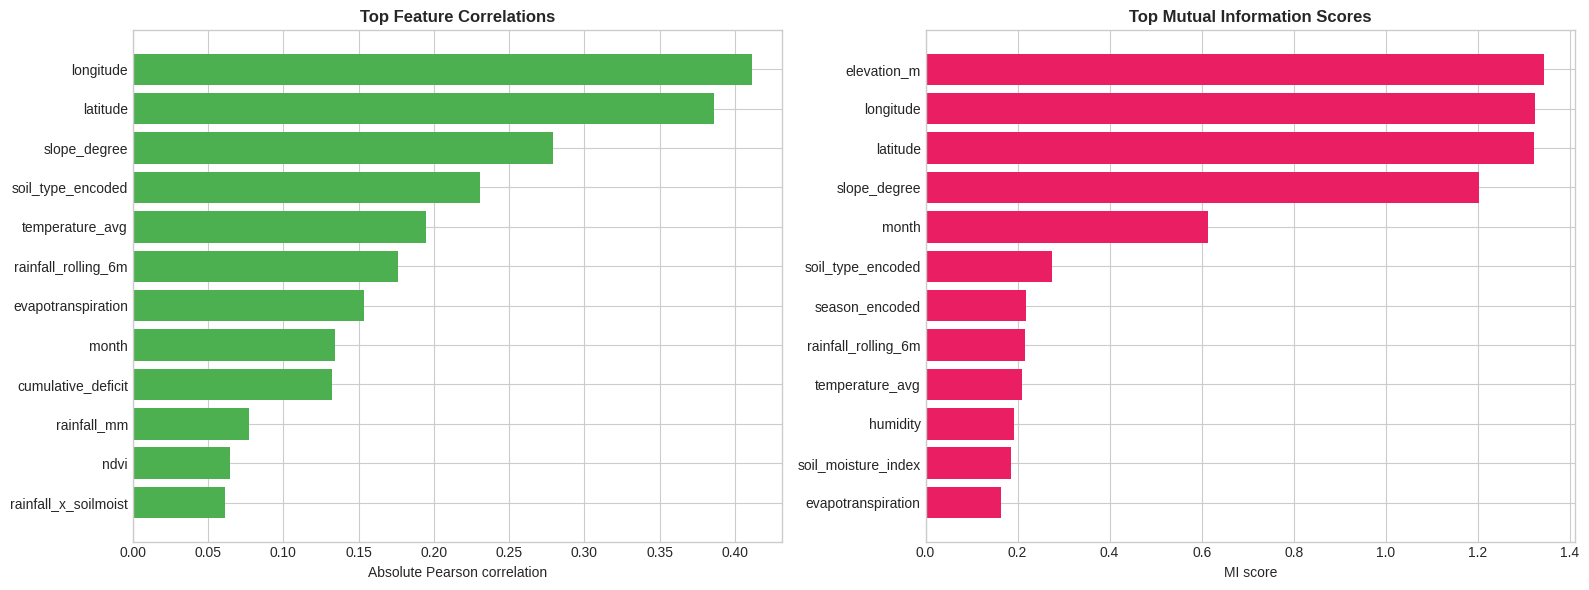

In [5]:
corr_df = X_train.copy()
corr_df[TARGET] = y_train
correlations = corr_df.corr(numeric_only=True)[TARGET].drop(TARGET).sort_values()
mi_scores = mutual_info_regression(X_train, y_train, random_state=42, n_neighbors=5)
mi_series = pd.Series(mi_scores, index=FEATURE_COLS).sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
top_corr = correlations.abs().sort_values(ascending=False).head(min(12, len(correlations)))
axes[0].barh(top_corr.index[::-1], top_corr.values[::-1], color='#4CAF50')
axes[0].set_title('Top Feature Correlations', fontweight='bold')
axes[0].set_xlabel('Absolute Pearson correlation')
top_mi = mi_series.head(min(12, len(mi_series)))
axes[1].barh(top_mi.index[::-1], top_mi.values[::-1], color='#E91E63')
axes[1].set_title('Top Mutual Information Scores', fontweight='bold')
axes[1].set_xlabel('MI score')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / '01_feature_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

## 🚀 Step 6: Baseline Model

In [6]:
def build_model(**params):
    if LIGHTGBM_AVAILABLE:
        return LGBMRegressor(random_state=42, n_jobs=-1, objective='regression', importance_type='gain', **params)
    return LGBMRegressor(random_state=42, **params)

def inverse_transform(pred_log):
    return np.clip(np.expm1(pred_log), 0, None)

def evaluate_predictions(y_true_raw, y_pred_raw):
    return {
        'r2': float(r2_score(y_true_raw, y_pred_raw)),
        'rmse': float(np.sqrt(mean_squared_error(y_true_raw, y_pred_raw))),
        'mae': float(mean_absolute_error(y_true_raw, y_pred_raw)),
        'mdape': float(np.median(np.abs((y_true_raw - y_pred_raw) / np.clip(y_true_raw, 1.0, None))) * 100),
    }

baseline_model = build_model(n_estimators=500, learning_rate=0.05, max_depth=6, subsample=0.85, colsample_bytree=0.85, reg_alpha=0.1, reg_lambda=1.0)
if LIGHTGBM_AVAILABLE:
    baseline_model.fit(X_train, y_train, eval_set=[(X_val, y_val)], eval_metric='rmse')
else:
    baseline_model.fit(X_train, y_train)

y_train_pred = inverse_transform(baseline_model.predict(X_train))
y_val_pred = inverse_transform(baseline_model.predict(X_val))
y_test_pred = inverse_transform(baseline_model.predict(X_test))

baseline_train = evaluate_predictions(y_train_raw.values, y_train_pred)
baseline_val = evaluate_predictions(y_val_raw.values, y_val_pred)
baseline_test = evaluate_predictions(y_test_raw.values, y_test_pred)
print(baseline_train)
print(baseline_val)
print(baseline_test)

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001001 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 3147
[LightGBM] [Info] Number of data points in the train set: 2024, number of used features: 19
[LightGBM] [Info] Start training from score 4.159920
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, 

## 🔁 Step 7: Hyperparameter Tuning

In [7]:
param_distributions = (
    {
        'n_estimators': [200, 400, 600, 800, 1000],
        'learning_rate': [0.01, 0.03, 0.05, 0.08, 0.1],
        'num_leaves': [31, 63, 127, 255],
        'max_depth': [-1, 4, 5, 6, 7, 8],
        'min_child_samples': [10, 20, 30, 40, 50],
        'subsample': [0.6, 0.7, 0.8, 0.9, 1.0],
        'colsample_bytree': [0.6, 0.7, 0.8, 0.9, 1.0],
        'reg_alpha': [0.0, 0.01, 0.1, 0.5, 1.0],
        'reg_lambda': [0.0, 0.5, 1.0, 1.5, 2.0],
    } if LIGHTGBM_AVAILABLE else {
        'n_estimators': [100, 200, 300, 500, 800],
        'learning_rate': [0.01, 0.03, 0.05, 0.08, 0.1],
        'max_depth': [2, 3, 4, 5, 6],
        'subsample': [0.6, 0.7, 0.8, 0.9, 1.0],
        'min_samples_leaf': [1, 2, 5, 10, 20],
        'min_samples_split': [2, 4, 6, 8, 10],
        'max_features': [None, 'sqrt', 'log2'],
    }
)
search = RandomizedSearchCV(
    estimator=build_model(),
    param_distributions=param_distributions,
    n_iter=25,
    scoring='r2',
    cv=TimeSeriesSplit(n_splits=5),
    n_jobs=-1,
    verbose=1,
    random_state=42,
    return_train_score=True,
)
search.fit(X_train, y_train)
print(search.best_score_)
print(search.best_params_)

Fitting 5 folds for each of 25 candidates, totalling 125 fits
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000183 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 3147
[LightGBM] [Info] Number of data points in the train set: 2024, number of used features: 19
[LightGBM] [Info] Start training from score 4.159920
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGB

## 🏆 Step 8: Final Model & Evaluation

In [8]:
best_params = search.best_params_.copy()
final_model = build_model(**best_params)
if LIGHTGBM_AVAILABLE:
    final_model.fit(X_train, y_train, eval_set=[(X_val, y_val)], eval_metric='rmse')
else:
    final_model.fit(X_train, y_train)

y_train_pred_final = inverse_transform(final_model.predict(X_train))
y_val_pred_final = inverse_transform(final_model.predict(X_val))
y_test_pred_final = inverse_transform(final_model.predict(X_test))

final_train = evaluate_predictions(y_train_raw.values, y_train_pred_final)
final_val = evaluate_predictions(y_val_raw.values, y_val_pred_final)
final_test = evaluate_predictions(y_test_raw.values, y_test_pred_final)
print(final_train)
print(final_val)
print(final_test)

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000442 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 3147
[LightGBM] [Info] Number of data points in the train set: 2024, number of used features: 19
[LightGBM] [Info] Start training from score 4.159920
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, 

## 📈 Step 9: Visual Diagnostics

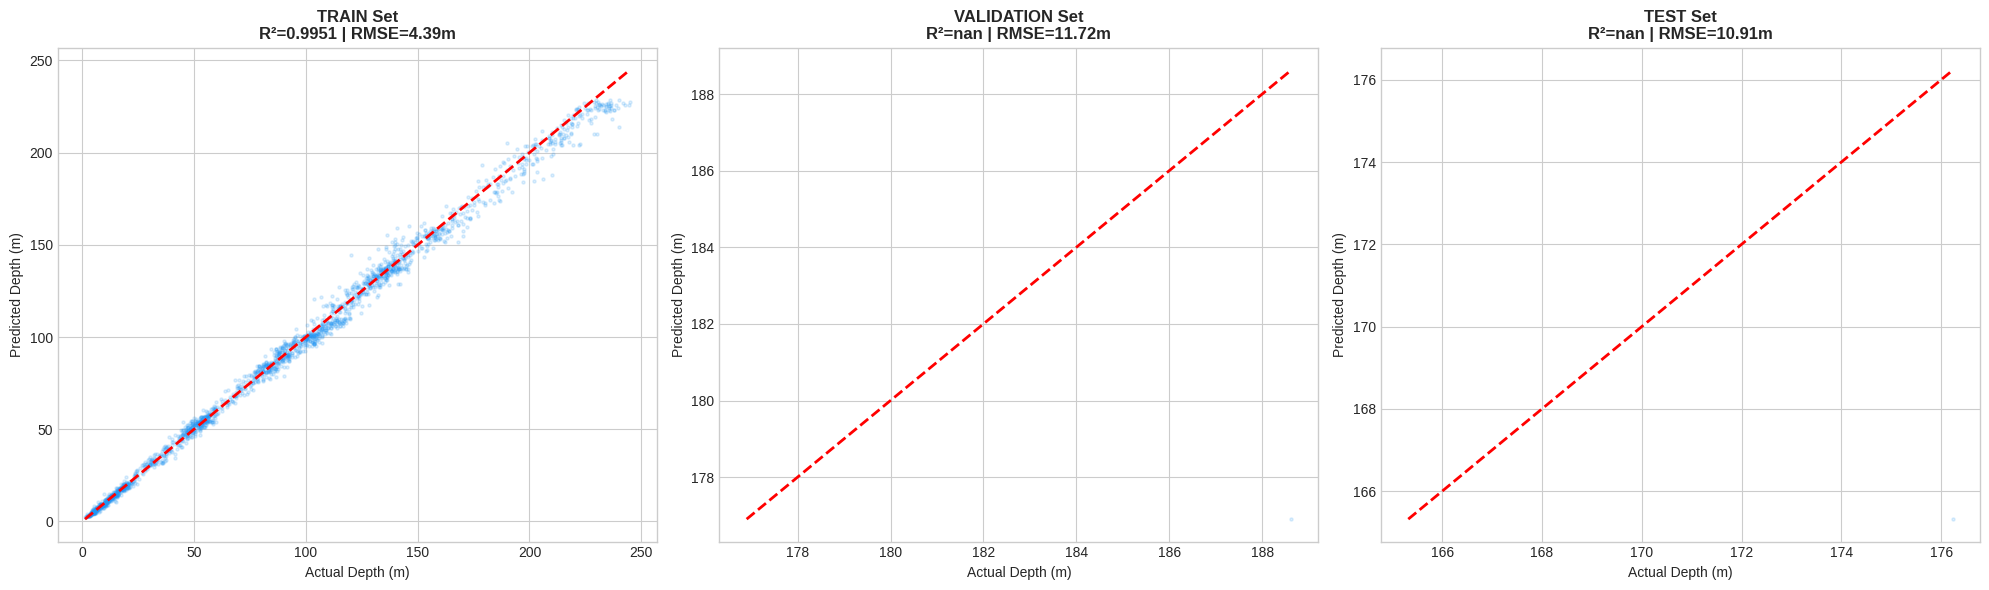

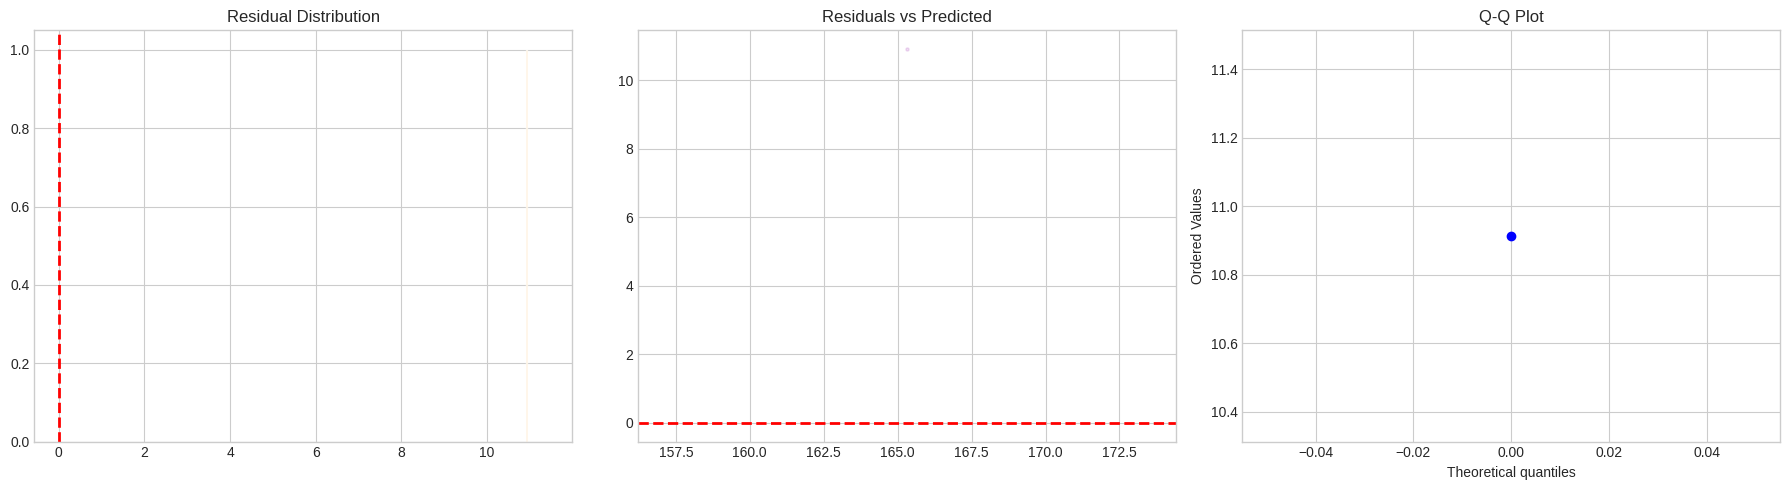

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
datasets = [
    ('TRAIN', y_train_raw.values, y_train_pred_final, final_train),
    ('VALIDATION', y_val_raw.values, y_val_pred_final, final_val),
    ('TEST', y_test_raw.values, y_test_pred_final, final_test),
]
for idx, (name, y_true, y_pred, metrics) in enumerate(datasets):
    ax = axes[idx]
    ax.scatter(y_true, y_pred, alpha=0.15, s=5, c='#2196F3')
    min_val = min(y_true.min(), y_pred.min())
    max_val = max(y_true.max(), y_pred.max())
    ax.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2)
    ax.set_title(f'{name} Set\nR²={metrics["r2"]:.4f} | RMSE={metrics["rmse"]:.2f}m', fontweight='bold')
    ax.set_xlabel('Actual Depth (m)')
    ax.set_ylabel('Predicted Depth (m)')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / '02_predicted_vs_actual.png', dpi=150, bbox_inches='tight')
plt.show()

residuals = y_test_raw.values - y_test_pred_final
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
axes[0].hist(residuals, bins=50, color='#FF9800', edgecolor='white', alpha=0.8)
axes[0].axvline(0, color='red', linewidth=2, linestyle='--')
axes[0].set_title('Residual Distribution')
axes[1].scatter(y_test_pred_final, residuals, alpha=0.15, s=5, c='#9C27B0')
axes[1].axhline(0, color='red', linewidth=2, linestyle='--')
axes[1].set_title('Residuals vs Predicted')
stats.probplot(residuals, dist='norm', plot=axes[2])
axes[2].set_title('Q-Q Plot')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / '03_residual_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

## 🌟 Step 10: Feature Importance & SHAP

            feature  importance
          longitude 8201.170364
       slope_degree 5006.650679
        elevation_m 3992.770516
           latitude 1809.072119
  soil_type_encoded 1209.856765
              month  714.966179
rainfall_rolling_6m  374.155779
    temperature_avg  271.830226
 evapotranspiration   28.620077
           humidity   25.955820


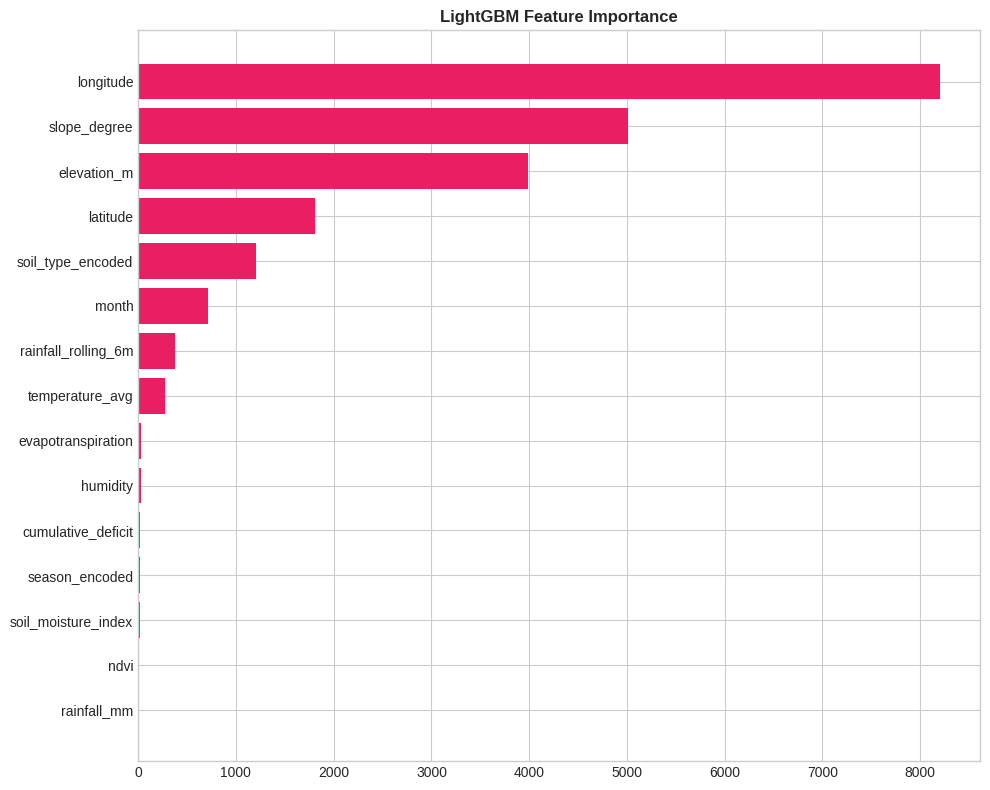

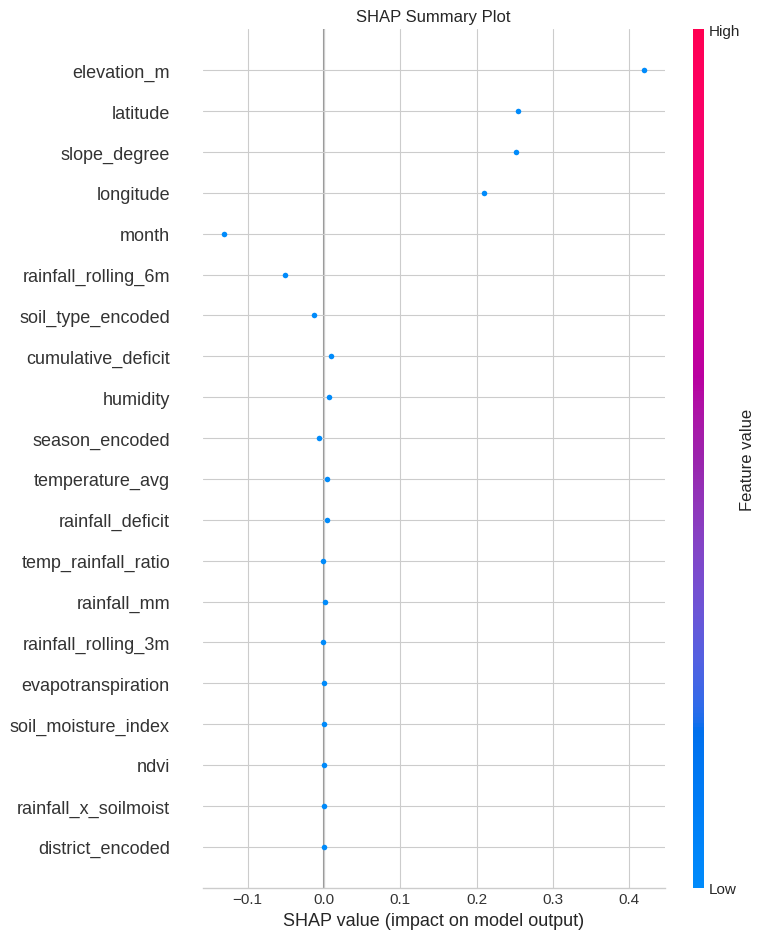

In [10]:
def get_feature_importance(model, feature_names, x_train, y_train):
    if LIGHTGBM_AVAILABLE and hasattr(model, 'booster_'):
        scores = model.booster_.feature_importance(importance_type='gain')
        return pd.DataFrame({'feature': feature_names, 'importance': scores}).sort_values('importance', ascending=False)
    if hasattr(model, 'feature_importances_'):
        return pd.DataFrame({'feature': feature_names, 'importance': model.feature_importances_}).sort_values('importance', ascending=False)
    perm = permutation_importance(model, x_train, y_train, n_repeats=10, random_state=42, n_jobs=-1)
    return pd.DataFrame({'feature': feature_names, 'importance': perm.importances_mean}).sort_values('importance', ascending=False)

importance_df = get_feature_importance(final_model, FEATURE_COLS, X_train, y_train)
print(importance_df.head(10).to_string(index=False))
fig, ax = plt.subplots(figsize=(10, 8))
top_imp = importance_df.head(min(15, len(importance_df)))
ax.barh(top_imp['feature'][::-1], top_imp['importance'][::-1], color='#E91E63')
ax.set_title('LightGBM Feature Importance', fontweight='bold')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / '04_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

if SHAP_AVAILABLE and len(X_test) > 0:
    shap_sample_size = min(2000, len(X_test))
    X_shap = X_test.sample(n=shap_sample_size, random_state=42)
    shap_explainer = shap.TreeExplainer(final_model)
    shap_values = shap_explainer(X_shap)
    plt.figure(figsize=(12, 10))
    shap.summary_plot(shap_values, X_shap, plot_type='dot', show=False, max_display=20)
    plt.title('SHAP Summary Plot')
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / '05_shap_summary.png', dpi=150, bbox_inches='tight')
    plt.show()
else:
    print('SHAP unavailable or test set empty; skipping SHAP plots.')

## 📈 Step 11: Cross-Validation & Learning Curve

CV R² mean: -1.4317 ± 1.4478
CV RMSE mean: 0.9680


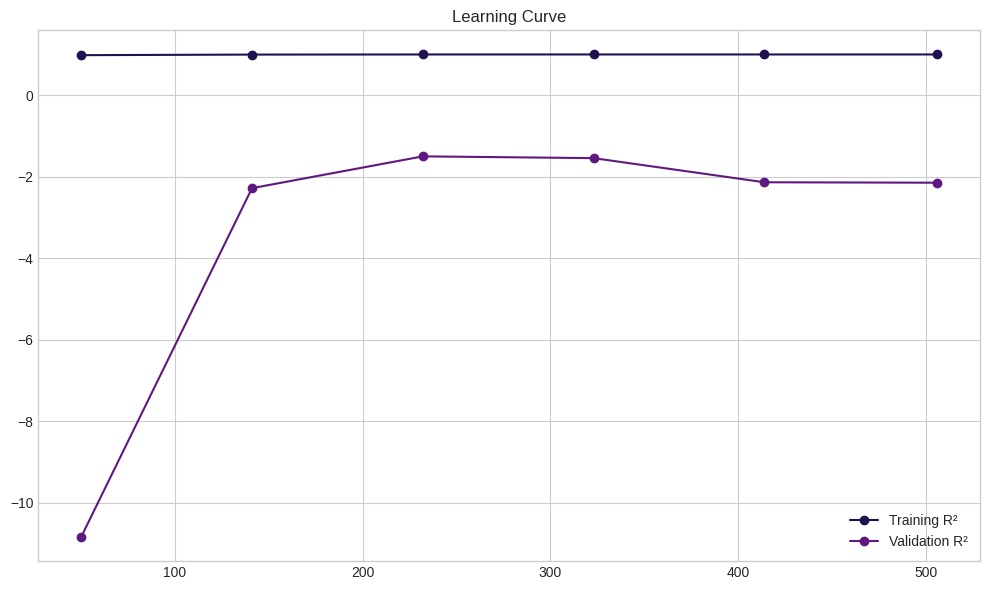

In [11]:
xgb_cv = final_model
cv_scores_r2 = cross_val_score(xgb_cv, X_train, y_train, cv=TimeSeriesSplit(n_splits=5), scoring='r2', n_jobs=-1)
cv_scores_rmse = cross_val_score(xgb_cv, X_train, y_train, cv=TimeSeriesSplit(n_splits=5), scoring='neg_root_mean_squared_error', n_jobs=-1)
print(f'CV R² mean: {cv_scores_r2.mean():.4f} ± {cv_scores_r2.std():.4f}')
print(f'CV RMSE mean: {-cv_scores_rmse.mean():.4f}')

train_sizes, train_scores, val_scores = learning_curve(xgb_cv, X_train, y_train, train_sizes=np.linspace(0.1, 1.0, 6), cv=TimeSeriesSplit(n_splits=3), scoring='r2', n_jobs=-1)
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(train_sizes, train_scores.mean(axis=1), 'o-', label='Training R²')
ax.plot(train_sizes, val_scores.mean(axis=1), 'o-', label='Validation R²')
ax.legend()
ax.set_title('Learning Curve')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / '06_learning_curve.png', dpi=150, bbox_inches='tight')
plt.show()

## 🔮 Step 12: Risk Classification & Inference

Risk classification accuracy: 100.0%
              precision    recall  f1-score   support

        SAFE       0.00      0.00      0.00         0
     WARNING       0.00      0.00      0.00         0
    CRITICAL       1.00      1.00      1.00         1
     EXTREME       0.00      0.00      0.00         0

    accuracy                           1.00         1
   macro avg       0.25      0.25      0.25         1
weighted avg       1.00      1.00      1.00         1



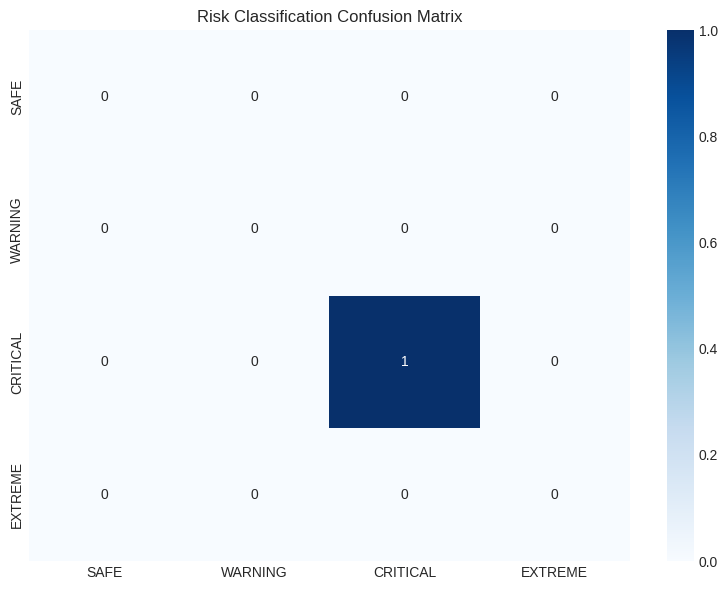

Sample predicted depth: 165.32m


In [12]:
def classify_risk(depth):
    if depth < 30:
        return 'SAFE'
    if depth < 100:
        return 'WARNING'
    if depth < 200:
        return 'CRITICAL'
    return 'EXTREME'

risk_order = ['SAFE', 'WARNING', 'CRITICAL', 'EXTREME']
y_true_risk = np.array([classify_risk(v) for v in y_test_raw.values])
y_pred_risk = np.array([classify_risk(v) for v in y_test_pred_final])
risk_accuracy = float((y_true_risk == y_pred_risk).mean() * 100)
print(f'Risk classification accuracy: {risk_accuracy:.1f}%')
print(classification_report(y_true_risk, y_pred_risk, labels=risk_order, zero_division=0))
cm = confusion_matrix(y_true_risk, y_pred_risk, labels=risk_order)
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=risk_order, yticklabels=risk_order, ax=ax)
ax.set_title('Risk Classification Confusion Matrix')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / '07_risk_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

sample_input = X_test.iloc[[0]].copy()
sample_prediction_log = final_model.predict(sample_input)[0]
sample_prediction = float(np.expm1(sample_prediction_log))
print(f'Sample predicted depth: {sample_prediction:.2f}m')

## 💾 Step 13: Save Artifacts

In [13]:
version_str = datetime.now().strftime('%Y%m%d_%H%M%S')
model_hash = hashlib.md5(str(best_params).encode()).hexdigest()[:8]
model_path = MODEL_DIR / 'lgbm_no_lag_best.pkl'
versioned_path = MODEL_DIR / f'lgbm_no_lag_{version_str}_{model_hash}.pkl'
native_path = MODEL_DIR / 'lgbm_no_lag_best.txt'
config_path = MODEL_DIR / 'lgbm_no_lag_config.json'
metrics_path = MODEL_DIR / 'lgbm_no_lag_metrics.json'

joblib.dump(final_model, model_path)
joblib.dump(final_model, versioned_path)
if LIGHTGBM_AVAILABLE and hasattr(final_model, 'booster_'):
    final_model.booster_.save_model(str(native_path))

with open(config_path, 'w', encoding='utf-8') as f:
    json.dump({
        'feature_columns': FEATURE_COLS,
        'target_column': TARGET,
        'target_transform': 'log1p',
        'inverse_transform': 'expm1',
        'excluded_columns': DROP_COLUMNS,
        'excluded_patterns': list(LAG_PATTERNS),
        'feature_groups': {
            'Meteorological': ['rainfall_mm', 'temperature_avg', 'temperature_max_c', 'temperature_min_c', 'humidity', 'evapotranspiration', 'evapotranspiration_mm'],
            'Soil / Hydrology': ['soil_moisture_index', 'runoff_mm', 'baseflow_mm', 'soil_type_encoded'],
            'Rolling Rainfall': ['rainfall_rolling_3m', 'rainfall_rolling_6m'],
            'Stress': ['rainfall_deficit', 'cumulative_deficit', 'temp_rainfall_ratio', 'drought_index', 'irrigation_demand_mm', 'water_stress_index'],
            'Temporal': ['month', 'season_encoded', 'season', 'month_sin', 'month_cos'],
            'Geospatial': ['latitude', 'longitude', 'elevation_m', 'slope_degree', 'district_encoded'],
            'Vegetation': ['ndvi'],
            'Engineered': ['rainfall_x_soilmoist'],
        },
        'split_strategy': 'year-based or fallback index-based',
        'lightgbm_available': LIGHTGBM_AVAILABLE,
    }, f, indent=2)

with open(metrics_path, 'w', encoding='utf-8') as f:
    json.dump({
        'model_version': f'{version_str}_{model_hash}',
        'best_params': best_params,
        'best_cv_r2': float(search.best_score_),
        'final_test': final_test,
        'risk_accuracy_pct': risk_accuracy,
        'train_rows': int(len(X_train)),
        'val_rows': int(len(X_val)),
        'test_rows': int(len(X_test)),
        'feature_count': int(len(FEATURE_COLS)),
        'trained_at': datetime.now().strftime('%Y-%m-%d %H:%M:%S'),
        'lightgbm_available': LIGHTGBM_AVAILABLE,
    }, f, indent=2, default=str)

print('Saved artifacts:')
print(model_path)
print(versioned_path)
print(native_path)
print(config_path)
print(metrics_path)

print('LightGBM notebook complete.')

Saved artifacts:
/content/drive/MyDrive/WPS_PRO/Models/engines/path1_temporal/saved_models/lgbm_no_lag_best.pkl
/content/drive/MyDrive/WPS_PRO/Models/engines/path1_temporal/saved_models/lgbm_no_lag_20260507_150323_636ac673.pkl
/content/drive/MyDrive/WPS_PRO/Models/engines/path1_temporal/saved_models/lgbm_no_lag_best.txt
/content/drive/MyDrive/WPS_PRO/Models/engines/path1_temporal/saved_models/lgbm_no_lag_config.json
/content/drive/MyDrive/WPS_PRO/Models/engines/path1_temporal/saved_models/lgbm_no_lag_metrics.json
LightGBM notebook complete.
